# Simple Imputer for Categorical Data
The notebook focuses on Categorical Data Imputation using a constant strategy.

**Categorical imputation is a preprocessing step where missing labels in non-numerical columns (like names, colors, or cities) are replaced to make the dataset complete for machine learning models.**

The notebook uses a "toy" Titanic dataset to demonstrate how to fill missing values in categorical features such as Cabin and Embarked. It primarily utilizes pandas for data manipulation and sklearn.impute.SimpleImputer for the imputation process.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day37-handling-missing-categorical-data/train.csv"

In [3]:
df = pd.read_csv(url, usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


Executes `df.isnull().mean()`, which calculates the percentage of null values for each column.

In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

.Plot the barplot for see the frequencies of the values

<Axes: xlabel='GarageQual'>

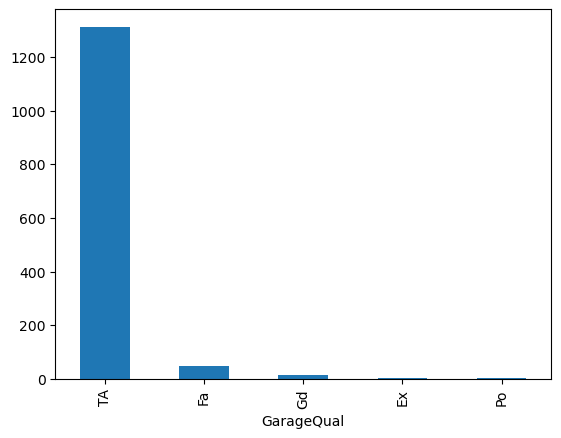

In [5]:
df['GarageQual'].value_counts().plot(kind='bar')

In [6]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Plot the `KDE` plot for check the distribution of the variable with mode value `TA` or with `NA`.


Text(0.5, 1.0, 'Garage Qual')

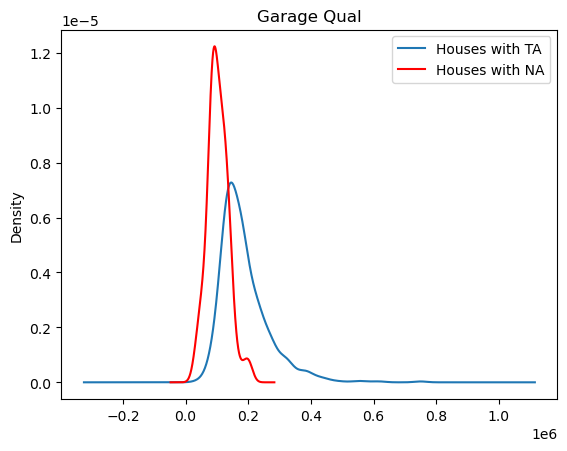

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA','Houses with NA']
ax.legend(lines, labels, loc='best')
plt.title("Garage Qual")

store the value in temp for further comparison

In [8]:
temp = df[df["GarageQual"] == 'TA']["SalePrice"]

Fill all `NA` with mode value `TA`.

In [10]:
df["GarageQual"].fillna('TA', inplace=True)

C:\Users\chour\AppData\Local\Temp\ipykernel_3160\1097026249.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GarageQual"].fillna('TA', inplace=True)


Now check the Value of `TA` is increase after the Imputation.

<Axes: xlabel='GarageQual'>

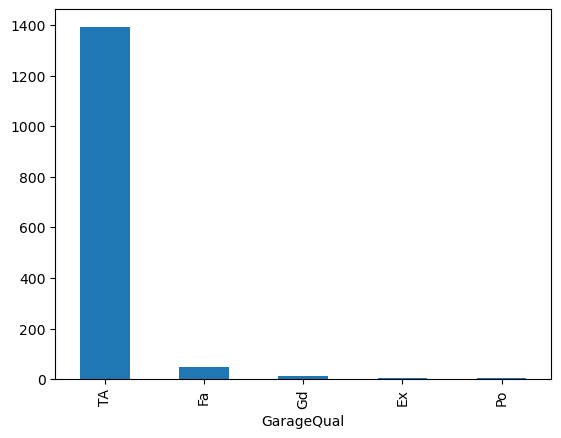

In [11]:
df['GarageQual'].value_counts().plot(kind='bar')

Again Comparison of the Data with TA where the Null value exists and after the Imputation.

Text(0.5, 1.0, 'Garage Qual')

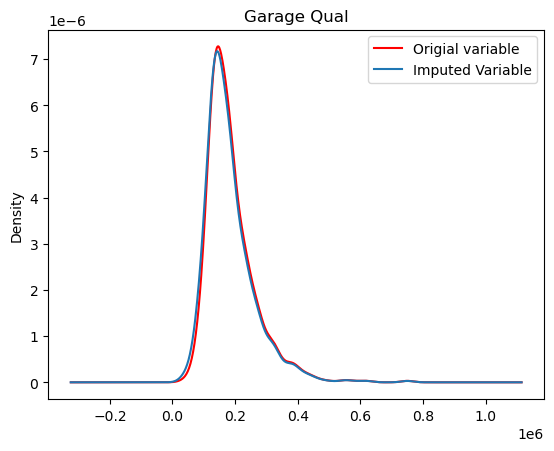

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, color='red')
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()

labels = ['Origial variable','Imputed Variable']
ax.legend(lines, labels, loc='best')
plt.title("Garage Qual")

Now do same process with `FireplaceQu` column

<Axes: xlabel='FireplaceQu'>

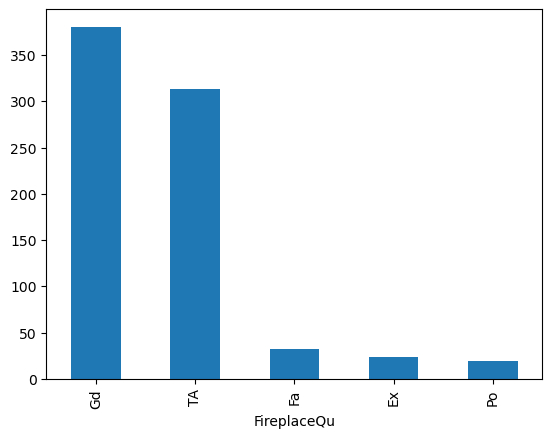

In [13]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [14]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

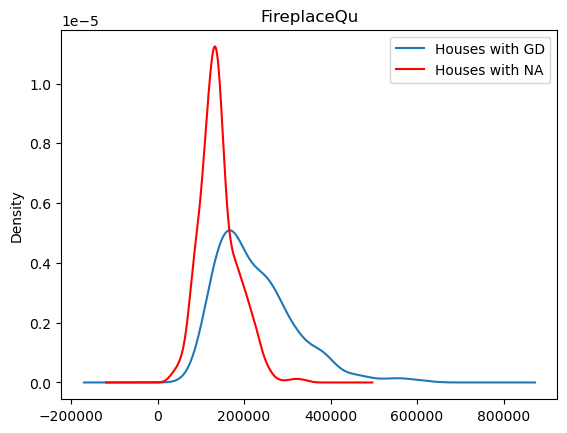

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with GD','Houses with NA']
ax.legend(lines, labels, loc='best')
plt.title("FireplaceQu")

In [16]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [17]:
df["FireplaceQu"].fillna('Gd', inplace=True)

C:\Users\chour\AppData\Local\Temp\ipykernel_3160\3883828024.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["FireplaceQu"].fillna('Gd', inplace=True)


After all those process we notice that the `Frequent_value_imputation` not work on `FireplaceQu` column because it contain `50%` missing values.

Text(0.5, 1.0, 'FireplaceQu')

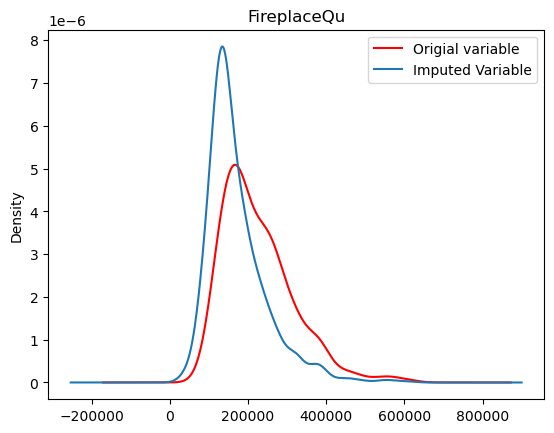

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, color='red')
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()

labels = ['Origial variable','Imputed Variable']
ax.legend(lines, labels, loc='best')
plt.title("FireplaceQu")

## Imputation using Sklearn

In [19]:
from sklearn.model_selection import  train_test_split
X_train, X_test,y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size = 0.2, random_state=42)

In [20]:
from sklearn.impute import  SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

In [21]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [22]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)